# Assigment I: Profiling Codes

## Task 1.1

In [1]:
import time
import timeit
import numpy as np

### time()

In [6]:
def checktick():
    M = 1000
    timesfound = np.empty(M)
    for i in range(M):
        t1 = time.time()  # get timestamp from timer
        t2 = time.time()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = time.time()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta * 1e9


print(checktick(), "ns")

238.4185791015625 ns


### timeit()

In [5]:
def checktick():
    M = 1000
    timesfound = np.empty(M)
    for i in range(M):
        t1 = timeit.default_timer()  # get timestamp from timer
        t2 = timeit.default_timer()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = timeit.default_timer()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta * 1e9


print(checktick(), "ns")

119.99873095192015 ns


### time_ns()

In [4]:
def checktick():
    M = 1000
    timesfound = np.empty(M, dtype='int')
    for i in range(M):
        t1 = time.time_ns()  # get timestamp from timer
        t2 = time.time_ns()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = time.time_ns()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta


print(checktick(), "ns")

150 ns


## Task 1.2

In [1]:
import timeit
import JuliaSet
import numpy as np
from functools import wraps


def timerdec(fn):
    @wraps(fn)
    def measure(*args, **kwargs):
        M = 30
        dt = np.empty(M)
        result = None
        for i in range(M):
            t1 = timeit.default_timer()
            result = fn(*args, **kwargs)
            t2 = timeit.default_timer()
            dt[i] = t2 - t1
        print(f"@timedec: {fn.__name__} takes {dt.mean()} +/- {dt.std()} s (Based on {M} runs)\n")
        return result

    return measure

In [2]:
JuliaSet.calc_pure_python = timerdec(JuliaSet.calc_pure_python)
JuliaSet.calc_pure_python(desired_width=1000, max_iterations=300)

@timedec: calc_pure_python takes 2.9398750937000537 +/- 0.01779296150542568 s (Based on 30 runs)



In [2]:
JuliaSet.calculate_z_serial_purepython = timerdec(JuliaSet.calculate_z_serial_purepython)
JuliaSet.calc_pure_python(desired_width=1000, max_iterations=300)

@timedec: calculate_z_serial_purepython takes 2.750056852699587 +/- 0.016442060883714315 s (Based on 30 runs)



## Task 1.3

In [4]:
%load_ext cProfile
%load_ext line_profiler
import pstats
from JuliaSet import calc_pure_python, calculate_z_serial_purepython

The cProfile module is not an IPython extension.
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [8]:
%prun -D p.stats calc_pure_python(desired_width=1000, max_iterations=300)

 
*** Profile stats marshalled to file 'p.stats'.


In [9]:
stats = pstats.Stats("p.stats")
stats.sort_stats("cumulative")
stats.print_stats()

Wed Jan 21 00:29:11 2026    p.stats

         36222621 function calls (36222612 primitive calls) in 5.969 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    5.920    5.920 {built-in method builtins.exec}
      2/1    0.018    0.009    3.342    3.342 <string>:1(<module>)
        1    0.000    0.000    3.328    3.328 /home/pavel/IdeaProjects/DD2358/Ass1/JuliaSet.py:20(calc_pure_python)
        1    2.214    2.214    3.328    3.328 /home/pavel/IdeaProjects/DD2358/Ass1/JuliaSet.py:58(calculate_z_serial_purepython)
        3    0.000    0.000    2.578    0.859 /usr/lib/python3.12/asyncio/base_events.py:1910(_run_once)
        3    0.338    0.113    2.578    0.859 /usr/lib/python3.12/selectors.py:451(select)
        3    1.409    0.470    2.114    0.705 {method 'poll' of 'select.epoll' objects}
 34219980    1.820    0.000    1.820    0.000 {built-in method builtins.abs}
  2002005    0.134    0.000   

In [10]:
#This displays the output of "python3 -m snakeviz profile.stats --server"
from IPython.display import HTML, display
display(HTML(filename="cProfile.html"))

In [11]:
p = %lprun -f calc_pure_python -f calculate_z_serial_purepython -r calc_pure_python(desired_width=1000, max_iterations=300)
p.print_stats()

Timer unit: 1e-09 s

Total time: 42.9022 s
File: /home/pavel/IdeaProjects/DD2358/Ass1/JuliaSet.py
Function: calc_pure_python at line 20

Line #      Hits         Time  Per Hit   % Time  Line Contents
    20                                           def calc_pure_python(desired_width, max_iterations):
    21                                               """Create a list of complex coordinates (zs) and complex parameters (cs),
    22                                               build Julia set"""
    23         1       1670.0   1670.0      0.0      x_step = (x2 - x1) / desired_width
    24         1        720.0    720.0      0.0      y_step = (y1 - y2) / desired_width
    25         1        530.0    530.0      0.0      x = []
    26         1        530.0    530.0      0.0      y = []
    27         1        510.0    510.0      0.0      ycoord = y2
    28      1001     250640.0    250.4      0.0      while ycoord > y1:
    29      1000     252825.0    252.8      0.0          y.append(

Compare with 1.2

## Task 1.4

In [1]:
%load_ext memory_profiler
from JuliaSet import calc_pure_python, calculate_z_serial_purepython

In [3]:
%mprun -f calc_pure_python -f calculate_z_serial_purepython calc_pure_python(desired_width=200, max_iterations=300)

In [2]:
%cat m.stats

Filename: JuliaSet.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20   48.805 MiB   48.805 MiB           1   @profile
    21                                         def calc_pure_python(desired_width, max_iterations):
    22                                             """Create a list of complex coordinates (zs) and complex parameters (cs),
    23                                             build Julia set"""
    24   48.805 MiB    0.000 MiB           1       x_step = (x2 - x1) / desired_width
    25   48.805 MiB    0.000 MiB           1       y_step = (y1 - y2) / desired_width
    26   48.809 MiB    0.004 MiB           1       x = []
    27   48.809 MiB    0.000 MiB           1       y = []
    28   48.809 MiB    0.000 MiB           1       ycoord = y2
    29   48.816 MiB    0.004 MiB         201       while ycoord > y1:
    30   48.816 MiB    0.004 MiB         200           y.append(ycoord)
    31   48.816 MiB    0.000 MiB         200           ycoord += y_step

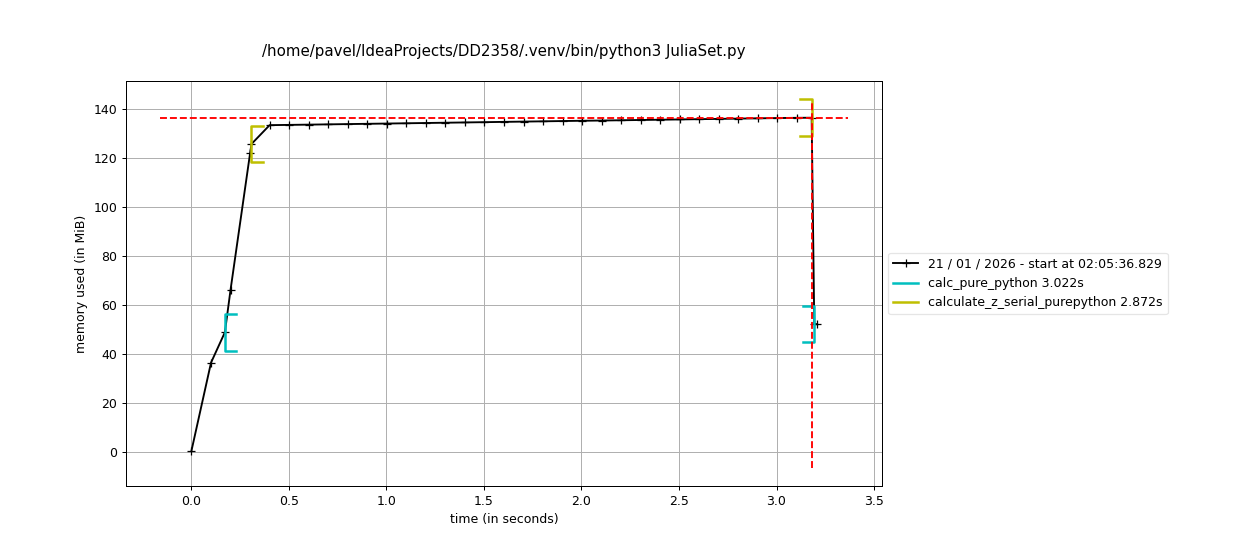

In [7]:
from IPython.display import Image
Image("memory_plot.png")

Again compare to Task 1.2